![A soccer pitch for an international match.](soccer-pitch.jpg)

You're working as a sports journalist at a major online sports media company, specializing in soccer analysis and reporting. You've been watching both men's and women's international soccer matches for a number of years, and your gut instinct tells you that more goals are scored in women's international football matches than men's. This would make an interesting investigative article that your subscribers are bound to love, but you'll need to perform a valid statistical hypothesis test to be sure!

While scoping this project, you acknowledge that the sport has changed a lot over the years, and performances likely vary a lot depending on the tournament, so you decide to limit the data used in the analysis to only official `FIFA World Cup` matches (not including qualifiers) since `2002-01-01`.

You create two datasets containing the results of every official men's and women's international football match since the 19th century, which you scraped from a reliable online source. This data is stored in two CSV files: `women_results.csv` and `men_results.csv`.

The question you are trying to determine the answer to is:

> Are more goals scored in women's international soccer matches than men's?

You assume a **10% significance level**, and use the following null and alternative hypotheses:

$H_0$ : The mean number of goals scored in women's international soccer matches is the same as men's.

$H_A$ : The mean number of goals scored in women's international soccer matches is greater than men's.

In [33]:
# Start your code here!
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin

In [34]:
# Load women_results.csv data head and details
women_results = pd.read_csv("women_results.csv")
print(women_results.head())
print(women_results.info())
print(women_results.value_counts("tournament"))
women_results["date"] = pd.to_datetime(women_results["date"])

   Unnamed: 0        date home_team  ... home_score  away_score        tournament
0           0  1969-11-01     Italy  ...          1           0              Euro
1           1  1969-11-01   Denmark  ...          4           3              Euro
2           2  1969-11-02   England  ...          2           0              Euro
3           3  1969-11-02     Italy  ...          3           1              Euro
4           4  1975-08-25  Thailand  ...          3           2  AFC Championship

[5 rows x 7 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4884 non-null   int64 
 1   date        4884 non-null   object
 2   home_team   4884 non-null   object
 3   away_team   4884 non-null   object
 4   home_score  4884 non-null   int64 
 5   away_score  4884 non-null   int64 
 6   tournament  4884 non-null   object
dtypes: int64(3), ob

In [35]:
# Load men_results.csv data head and details
men_results = pd.read_csv("men_results.csv")
print(men_results.head())
print(men_results.info())
print(women_results.value_counts("tournament"))
men_results["date"] = pd.to_datetime(men_results["date"])

   Unnamed: 0        date home_team  ... home_score  away_score  tournament
0           0  1872-11-30  Scotland  ...          0           0    Friendly
1           1  1873-03-08   England  ...          4           2    Friendly
2           2  1874-03-07  Scotland  ...          2           1    Friendly
3           3  1875-03-06   England  ...          2           2    Friendly
4           4  1876-03-04  Scotland  ...          3           0    Friendly

[5 rows x 7 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44353 entries, 0 to 44352
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  44353 non-null  int64 
 1   date        44353 non-null  object
 2   home_team   44353 non-null  object
 3   away_team   44353 non-null  object
 4   home_score  44353 non-null  int64 
 5   away_score  44353 non-null  int64 
 6   tournament  44353 non-null  object
dtypes: int64(3), object(4)
memory usage: 2.4+ MB
None

In [36]:
# Filter data to FIFA World Cup matches since 2002-01-01
women_dataset = women_results[(women_results["date"] > "2002-01-01") & (women_results["tournament"].isin(["FIFA World Cup"]))]

men_dataset = men_results[(men_results["date"] > "2002-01-01") & (men_results["tournament"].isin(["FIFA World Cup"]))]
print(women_dataset)

      Unnamed: 0       date  ... away_score      tournament
1600        1600 2003-09-20  ...          3  FIFA World Cup
1601        1601 2003-09-20  ...          0  FIFA World Cup
1602        1602 2003-09-20  ...          1  FIFA World Cup
1603        1603 2003-09-20  ...          0  FIFA World Cup
1604        1604 2003-09-21  ...          1  FIFA World Cup
...          ...        ...  ...        ...             ...
4465        4465 2019-06-29  ...          2  FIFA World Cup
4466        4466 2019-07-02  ...          2  FIFA World Cup
4467        4467 2019-07-03  ...          0  FIFA World Cup
4468        4468 2019-07-06  ...          2  FIFA World Cup
4469        4469 2019-07-07  ...          0  FIFA World Cup

[200 rows x 7 columns]


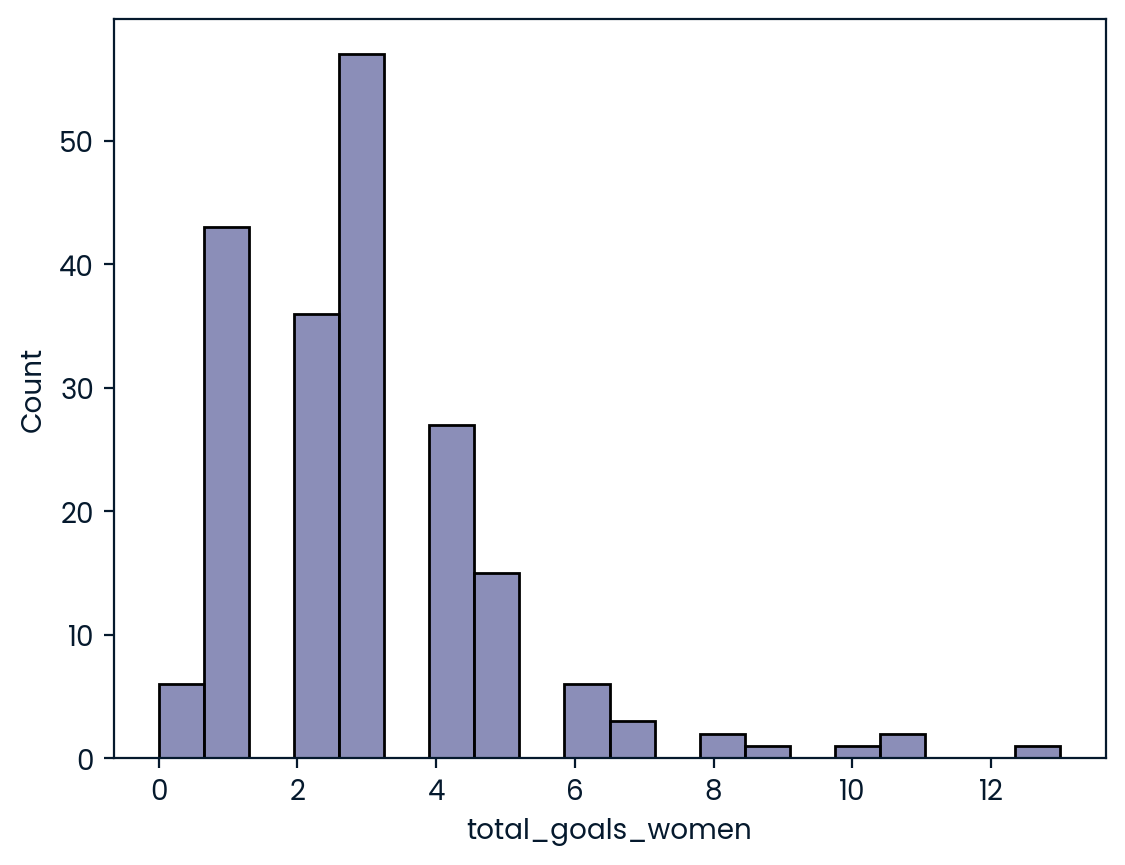

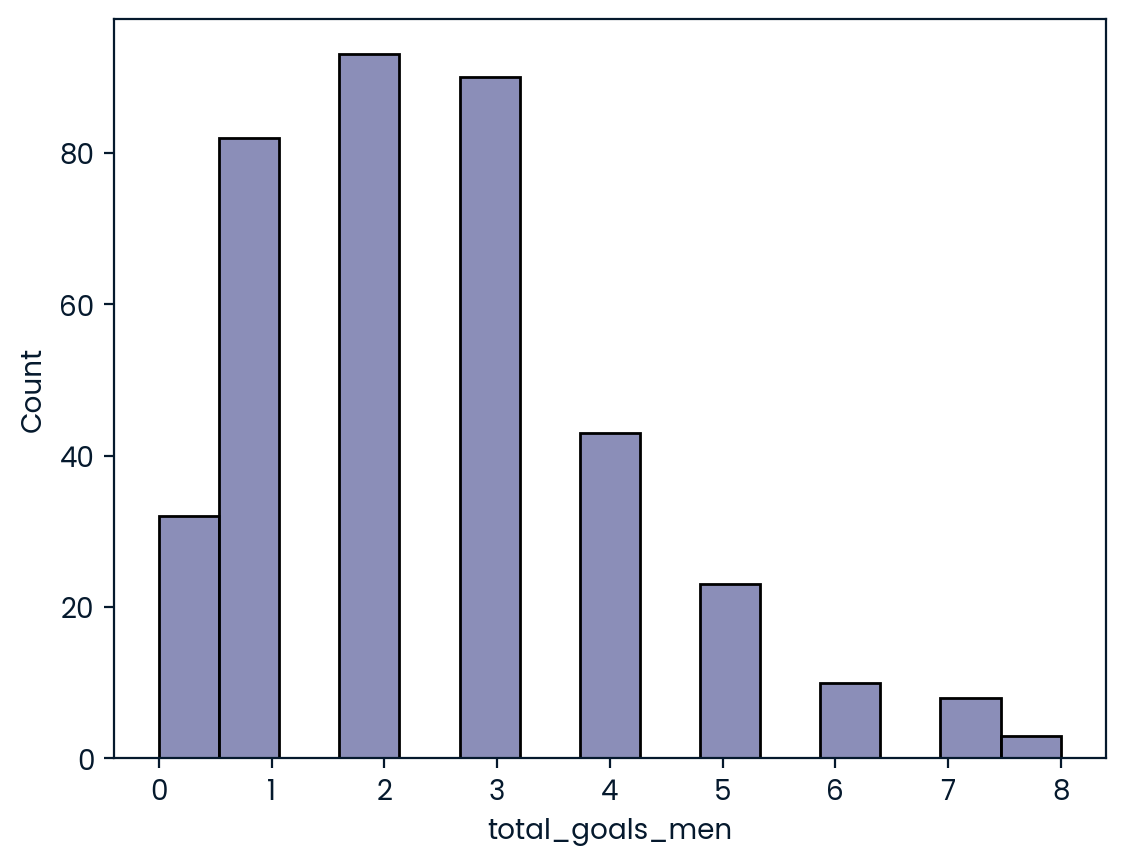

In [37]:
# H0: the mean number of goals scored in women's international soccer matches is THE SAME as men's
# HA: the mean number of goals scored in women's international soccer matches is GREATER than men's
# Perform a right-tailed test, two-sample t-test
# Check sample size and normality of each distribution
women_dataset["total_goals_women"] = women_dataset["home_score"] + women_dataset["away_score"]
women_hist = sns.histplot(data=women_dataset, x="total_goals_women")
plt.show(women_hist)

men_dataset["total_goals_men"] = men_dataset["home_score"] + men_dataset["away_score"]
men_hist = sns.histplot(data=men_dataset, x="total_goals_men")
plt.show(men_hist)

# Goals are not normally distributed and are right skewed
# Perform a Mann-Whitney-U test

In [40]:
# perform an appropriate hypothesis test (mwu) to determine p-value
# p-value and result of the test must be stored in a dictionary called result_dict
# p-val is the p-value
# result is either string "fail to reject" or "reject"
alpha = 0.1

combined_dataset = pd.concat([women_dataset, men_dataset], ignore_index=True)

mwu = pingouin.mwu(x=combined_dataset["total_goals_women"], y= combined_dataset["total_goals_men"], alternative="greater")
print(mwu)

p_val = mwu["p-val"].values[0]

if p_val <= alpha:
    result = "reject"
else:
    result = "fail to reject"

result_dict = {"p_val": p_val, "result": result}
print(result_dict)

       U-val alternative     p-val       RBC      CLES
MWU  43273.0     greater  0.005107 -0.126901  0.563451
{'p_val': 0.005106609825443641, 'result': 'reject'}
